## Model Creation

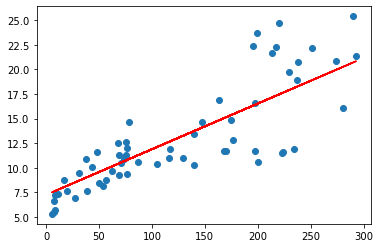

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# read the dataset
df = pd.read_csv(".\data\Advertising.csv")

# dropping
df.drop(['Unnamed: 0','Radio','Newspaper'],axis=1,inplace=True)

# Feature Selection and Target
X = df[['TV']]
y = df['Sales']

# Splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Algorithm Applying
slr = LinearRegression()  
slr.fit(X_train, y_train)

# predicitons on X_test
y_pred = slr.predict(X_test)

# Creating the dataset from actual and predicted values
slr_diff = pd.DataFrame({'Actual value': y_test, 'Predicted value': y_pred})

# Plotting the graph
plt.scatter(X_test,y_test)
plt.plot(X_test,y_pred, 'Red')
plt.show()

### Discusion:
    
    -> Making algorithm to learn data is very easy.
    
    -> Calculating the model performance is very important.
    
    -> Based on model performance we are going to select the algorithm
    
### Model Performance 

    -> MAE
    
    -> MSE
    
    -> RMSE
    
    -> R Square
    
    -> Adjusted R Squared

## 1) Mean Absolute Error(MAE)

#### Definition:

MAE is a very simple metric which calculates the absolute difference between actual and predicted values.

#### Discussion

    -> To better understand, let’s take an example you have input data and output data and use Linear Regression, which draws a best-fit line.

    -> Now you have to find the MAE of your model which is basically a mistake made by the model known as an error. Now find the difference between the actual value and predicted value that is an absolute error but we have to find the mean absolute of the complete dataset.

    -> So, sum all the errors and divide them by a total number of observations And this is MAE. And we aim to get a minimum MAE because this is a loss.

#### Advantage

    -> The MAE you get is in the same unit as the output variable.

    -> It is most Robust to outliers.

#### Disadvantage

    -> The graph of MAE is not differentiable so we have to apply various optimizers like Gradient descent which can be differentiable.

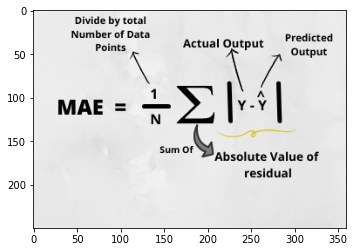

In [11]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# Read Images
img = mpimg.imread("./Images/mae.png")
# Output Images
plt.imshow(img)
plt.show()

In [9]:
from sklearn.metrics import mean_absolute_error
print("Mean Absolute Error:",round(mean_absolute_error(y_test,y_pred),2))

Mean Absolute Error: 2.28


## 2) Mean Squared Error(MSE)

#### Definition:

MSE is a most used and very simple metric with a little bit of change in mean absolute error. Mean squared error states that finding the squared difference between actual and predicted value.

#### Discussion

    -> So, above we are finding the absolute difference and here we are finding the squared difference.

    -> What actually the MSE represents? 
    
        It represents the squared distance between actual and predicted values. we perform squared to avoid the cancellation of negative terms and it is the benefit of MSE.

#### Advantage

    -> The graph of MSE is differentiable, so you can easily use it as a loss function.

#### Disadvantages

    -> The value you get after calculating MSE is a squared unit of output. for example, the output variable is in meter(m) then after calculating MSE the output we get is in meter squared.

    -> If you have outliers in the dataset then it penalizes the outliers most and the calculated MSE is bigger. So, in short, It is not Robust to outliers which were an advantage in MAE.

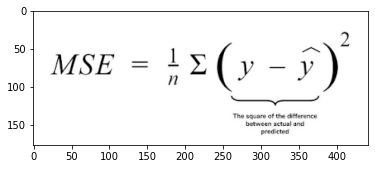

In [12]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# Read Images
img = mpimg.imread("./Images/mse.png")
# Output Images
plt.imshow(img)
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error
print("Mean Square Error:",round(mean_squared_error(y_test,y_pred),2))

Mean Square Error: 8.97


## 3) Root Mean Squared Error(RMSE)

#### Definition:

As RMSE is clear by the name itself, that it is a simple square root of mean squared error.

#### Discussion

    -> Most of the time people use RMSE as an evaluation metric and mostly when you are working with deep learning techniques the most preferred metric is RMSE.

#### Advantage

    -> The output value you get is in the same unit as the required output variable which makes interpretation of loss easy.

#### Disadvantages

    -> It is not that robust to outliers as compared to MAE.



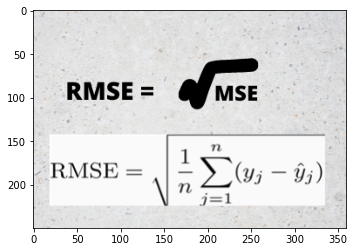

In [15]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# Read Images
img = mpimg.imread("./Images/rmse.png")
# Output Images
plt.imshow(img)
plt.show()

In [17]:
print("RMSE:",round(np.sqrt(mean_squared_error(y_test,y_pred)),2))

RMSE: 3.0


## 4) Root Mean Squared Log Error(RMSLE)

Taking the log of the RMSE metric slows down the scale of error. The metric is very helpful when you are developing a model without calling the inputs. In that case, the output will vary on a large scale.

To control this situation of RMSE we take the log of calculated RMSE error and resultant we get as RMSLE.

To perform RMSLE we have to use the NumPy log function over RMSE.

It is a very simple metric that is used by most of the datasets hosted for Machine Learning competitions.

In [18]:
print("RMSE",np.log(np.sqrt(mean_squared_error(y_test,y_pred))))

RMSE 1.096998088182974


## 5) R Squared (R2)

R2 score is a metric that tells the performance of your model, not the loss in an absolute sense that how many wells did your model perform.

In contrast, MAE and MSE depend on the context as we have seen whereas the R2 score is independent of context.

So, with help of R squared we have a baseline model to compare a model which none of the other metrics provides. The same we have in classification problems which we call a threshold which is fixed at 0.5. So basically R2 squared calculates how must regression line is better than a mean line.

Hence, R2 squared is also known as Coefficient of Determination or sometimes also known as Goodness of fit.

Now, how will you interpret the R2 score? suppose If the R2 score is zero then the above regression line by mean line is equal means 1 so 1-1 is zero. So, in this case, both lines are overlapping means model performance is worst, It is not capable to take advantage of the output column.

Now the second case is when the R2 score is 1, it means when the division term is zero and it will happen when the regression line does not make any mistake, it is perfect. In the real world, it is not possible.

So we can conclude that as our regression line moves towards perfection, R2 score move towards one. And the model performance improves.

The normal case is when the R2 score is between zero and one like 0.8 which means your model is capable to explain 80 per cent of the variance of data.

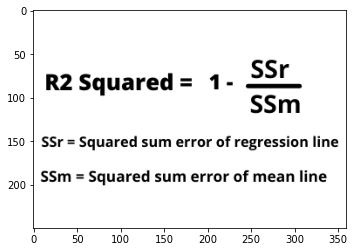

In [19]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# Read Images
img = mpimg.imread("./Images/rsquare.png")
# Output Images
plt.imshow(img)
plt.show()

In [20]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print(r2)

0.6714477229302764


## 6) Adjusted R Squared


The disadvantage of the R2 score is while adding new features in data the R2 score starts increasing or remains constant but it never decreases because It assumes that while adding more data variance of data increases.

But the problem is when we add an irrelevant feature in the dataset then at that time R2 sometimes starts increasing which is incorrect.

Hence, To control this situation Adjusted R Squared came into existence.

Now as K increases by adding some features so the denominator will decrease, n-1 will remain constant. R2 score will remain constant or will increase slightly so the complete answer will increase and when we subtract this from one then the resultant score will decrease. so this is the case when we add an irrelevant feature in the dataset.

And if we add a relevant feature then the R2 score will increase and 1-R2 will decrease heavily and the denominator will also decrease so the complete term decreases, and on subtracting from one the score increases.

Hence, this metric becomes one of the most important metrics to use during the evaluation of the model.

In [22]:
n=40
k=1
adj_r2_score = 1 - ((1-r2)*(n-1)/(n-k-1))
print(adj_r2_score)

0.6628016103758101
